In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pd_lfs import read_parquet
from vscodenb import set_vscode_theme
set_vscode_theme()

from geneinfo.genelist import GeneList as glist
from geneinfo.plot import upset

In [2]:
df = pd.read_csv('../results/mao2024/gene_disrupted.matrix.tsv', sep='\t')
df = df.loc[df.gene_type == 'protein_coding']
df = df.drop(columns=['gene_id', 'gene_type', 'chrom'])
#df.set_index('gene').groupby('chrom').apply(lambda df: df.sum() / df.index.size)
df = df.set_index('gene')
df

,Bonobo,Chimpanzee,Gibbon,Gorilla,Macaque_indian,Marmoset,Orangutan,Owl_monkey
gene,,,,,,,,
AAMDC,0,0,0,0,0,0,0,1
ABCA10,0,0,1,0,0,0,0,1
ABCA13,0,0,0,1,0,0,0,0
ABCA9,0,0,1,0,0,1,0,1
ABCC12,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...
ZPLD1,0,0,0,0,0,1,0,1
ZRANB3,0,0,0,0,1,0,0,0
ZSCAN31,0,0,0,0,0,0,0,1


In [ ]:
plot_df = df.loc[(df.Bonobo == 1)]
print('@' + ','.join(plot_df.index.to_list()))
plot_df

@AC114267,AC236972,ACSM1,ADAMTS13,ADAMTS20,AIMP2,APOL4,ASB15,ATAD3C,BTNL2,C12ORF54,C12ORF60,C6ORF15,CCDC40,CLPB,DGLUCY,FMO1,FSIP2,GLB1L2,GLT6D1,IL37,IL6R,ITFG2,KLHDC8A,KRTAP19-6,LCE5A,LYPD6,MAGEC1,MAL2,MALRD1,MAP4K1,MROH2A,MUC12,MUC4,NAT16,NLRP10,NLRP4,NRG1,NWD1,OR10G4,OR11A1,OR2T10,OR7C1,OSCAR,PCDH15,PLA2G6,PRH2,PRMT2,RFPL1,RRP8,SAMD9,SFSWAP,SLC22A24,SLC35G4,SMCO2,TBC1D8B,TMEM175,TTC23,UBXN11,VCAM1,ZNF112,ZNF280C


,Bonobo,Chimpanzee,Gibbon,Gorilla,Macaque_indian,Marmoset,Orangutan,Owl_monkey
gene,,,,,,,,
AC114267,1,1,0,0,0,0,0,0
AC236972,1,0,1,1,0,0,0,0
ACSM1,1,1,0,0,0,0,0,0
ADAMTS13,1,1,0,0,0,0,0,0
ADAMTS20,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
TTC23,1,1,0,0,0,1,0,1
UBXN11,1,1,1,1,1,1,1,1
VCAM1,1,1,0,0,0,0,0,0


# Seems odd that DMD and CASK are not among the Bonobo lost genes as the Eichler paper says....

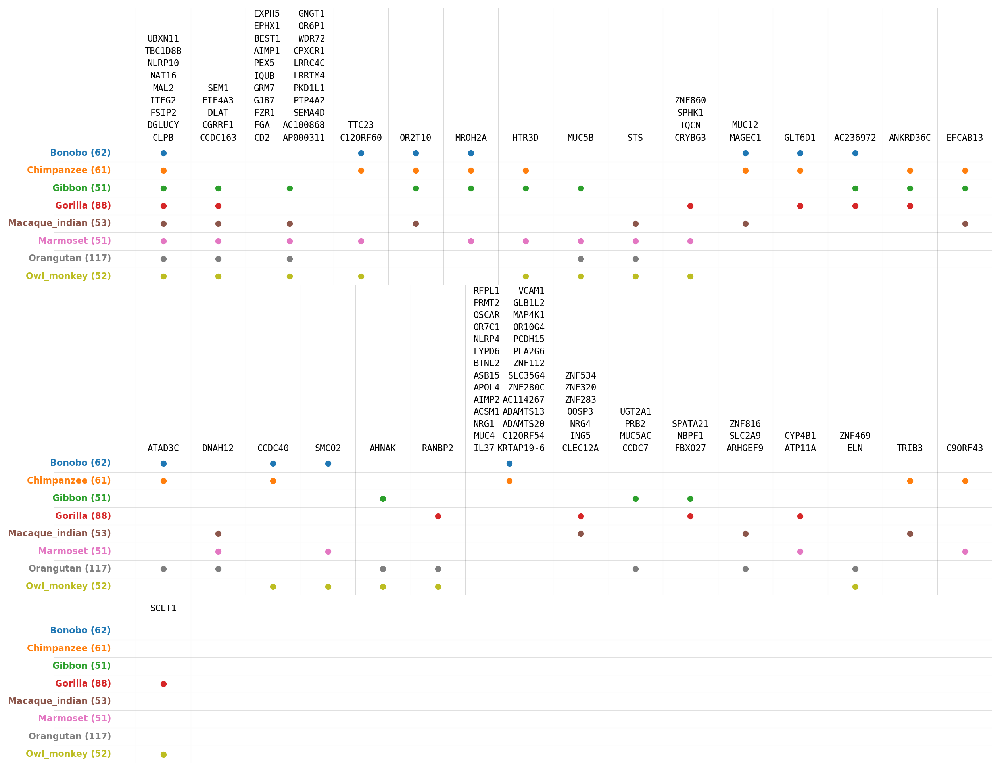

In [ ]:
plot_df = df.loc[(df.Gorilla == 1) | (df.Chimpanzee == 1) | (df.Bonobo == 1) | (df.Orangutan == 1)]
gene_sets = {sp: plot_df.index[(plot_df[sp] == 1)].to_list() for sp in plot_df.columns}
upset(
    gene_sets,
    sort_by='degree',
    # sort_by='groups',
    # sort_by='ordered',
    col_width=0.75,
    set_row_h=0.20,
    size_bar_cols=1,
    dot_empty_color='none',
    #  mode='inclusive',
    gene_pad=0.15,
    label_fontsize=8,
    gene_fontsize=8,
    two_col_ratio=1.6,
    show_count=False,
    wrap=True,
    )

# seems odd that only one gene is lost on an external lineage...

In [4]:
plot_df = df.loc[(df.Gorilla == 1) & (df.Chimpanzee == 0) & (df.Bonobo == 0) & (df.Orangutan == 0)]
print('@' + ','.join(plot_df.index.to_list()))
plot_df

@ABCA13,AC092329,ADAM2,ARHGAP9,ARSB,ATP11A,C16ORF96,CAPN5,CCDC171,CDR2,CEP192,CFHR2,CLEC12A,CRLF3,CRYBG3,CYP4B1,CYYR1,DEFB124,DNAH6,FAIM,FAM161B,FAM47C,FBXO27,FCRLA,FNDC1,ING5,IQCN,KLRC3,LITAFD,LMBR1,MADD,MNS1,NBPF1,NBPF3,NPIPB13,NRG4,OOSP3,OR10K1,OR2T33,OR6C1,POTED,PRODH2,RAD51D,SCLT1,SEBOX,SELENOV,SMIM11A,SPATA1,SPATA21,SPHK1,SYNM,TAAR8,TEDDM1,TRIM69,USP32,ZNF177,ZNF283,ZNF320,ZNF33B,ZNF534,ZNF585B,ZNF586,ZNF587,ZNF626,ZNF716,ZNF720,ZNF721,ZNF735,ZNF83,ZNF860


,Bonobo,Chimpanzee,Gibbon,Gorilla,Macaque_indian,Marmoset,Orangutan,Owl_monkey
gene,,,,,,,,
ABCA13,0,0,0,1,0,0,0,0
AC092329,0,0,0,1,0,0,0,0
ADAM2,0,0,0,1,0,0,0,0
ARHGAP9,0,0,0,1,0,0,0,0
ARSB,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
ZNF720,0,0,0,1,0,0,0,0
ZNF721,0,0,0,1,0,0,0,0
ZNF735,0,0,0,1,0,0,0,0


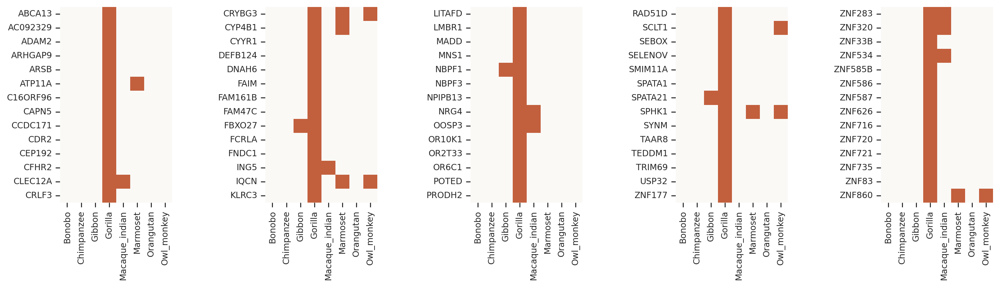

In [5]:
with sns.axes_style('ticks'), sns.plotting_context('paper', font_scale=1):
    nr_cols = 5
    step = (len(plot_df) // nr_cols)
    fig, axes = plt.subplots(1, nr_cols, figsize=(3*nr_cols, max(3, 0.3*step)))
    if len(plot_df) % step:
        step += 1
    for i, n in enumerate(range(0, len(plot_df), step)):
        sns.heatmap(plot_df.iloc[n:n+step], ax=axes[i], cbar=False, square=True, 
                    cmap=matplotlib.colors.ListedColormap(['#FAF9F6', '#C25F3D'])
                    )
        plt.xticks(rotation=90) 
        axes[i].set_ylabel('')
    plt.tight_layout()

In [5]:

# plot_df = _df.loc[_df.sum(axis=1) > 1]
# plot_df = _df.loc[_df.sum(axis=1) == 2]
# plot_df = _df.loc[(_df.sum(axis=1) == 2) & ((_df.Gorilla != _df.Orangutan) | (_df.Chimpanzee != _df.Bonobo))]

# plot_df = _df.loc[(_df.Macaque_indian == 0) & (_df.sum(axis=1) > 1) & ((_df.Gorilla != _df.Orangutan) | (_df.Chimpanzee != _df.Bonobo))]
plot_df = df.loc[((df.Macaque_indian == 0) | (df.Marmoset == 0) | (df.Owl_monkey == 0) | (df.Gibbon == 0)) & ((df.Bonobo == 1) | (df.Chimpanzee == 1) | (df.Gorilla == 1) | (df.Orangutan == 1)) ]
print('@' + ','.join(plot_df.index.to_list()))
plot_df

@ABCA13,AC092329,AC114267,AC236972,ACSM1,ADAM2,ADAMTS13,ADAMTS20,ADAMTSL3,AGPAT3,AHNAK,AIMP2,ANKRD36C,ANP32D,APOL4,ARHGAP21,ARHGAP4,ARHGAP9,ARHGEF9,ARSB,ASB15,ATAD3C,ATP11A,ATP6V0A4,AXIN1,BBS9,BTNL2,C11ORF24,C12ORF54,C12ORF60,C16ORF96,C17ORF97,C6ORF15,C9ORF43,CAPN5,CASC1,CATSPER1,CCDC171,CCDC40,CCDC7,CCDC91,CD163L1,CDR2,CEP192,CFAP46,CFHR2,CLEC12A,CNTROB,CRLF3,CRYBG3,CYP2W1,CYP4B1,CYYR1,DEFB124,DEFB135,DIS3L2,DNAH1,DNAH12,DNAH6,EFCAB13,ELN,ELP5,ERICH1,ERVV-1,ETDC,FAIM,FAM161B,FAM170B,FAM47C,FBH1,FBXO27,FBXO39,FCRLA,FMO1,FNDC1,GDPD2,GLB1L2,GLT6D1,HMG20A,HSD17B6,HTR3D,IL37,IL6R,ING5,IQCN,KCNT1,KHDC1,KLHDC8A,KLRC3,KRTAP19-6,LCE2D,LCE5A,LITAFD,LMBR1,LYPD6,MADD,MAGEC1,MALRD1,MAMDC4,MAP4K1,MAP7,MAPK8IP2,MAS1L,MCTP2,MED16,MNS1,MOGAT1,MROH2A,MS4A4E,MUC12,MUC4,MUC5AC,MUC5B,NBPF1,NBPF11,NBPF3,NLRP4,NPIPB13,NRG1,NRG4,NWD1,NXNL2,OOSP3,OR10G4,OR10K1,OR11A1,OR2J3,OR2M7,OR2T10,OR2T33,OR2T35,OR3A2,OR6B2,OR6C1,OR6C65,OR7A17,OR7C1,OR9A2,OSCAR,PCDH15,PCDHB6,PDZD2,PKHD1L1,PLA2G6,POTED,PRB2,PRDM9,PRF1,PRH2

,Bonobo,Chimpanzee,Gibbon,Gorilla,Macaque_indian,Marmoset,Orangutan,Owl_monkey
gene,,,,,,,,
ABCA13,0,0,0,1,0,0,0,0
AC092329,0,0,0,1,0,0,0,0
AC114267,1,1,0,0,0,0,0,0
AC236972,1,0,1,1,0,0,0,0
ACSM1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
ZNF721,0,0,0,1,0,0,0,0
ZNF735,0,0,0,1,0,0,0,0
ZNF816,0,0,0,0,1,0,1,0


In [ ]:
with sns.axes_style('ticks'), sns.plotting_context('paper', font_scale=1):
    nr_cols = 5
    step = (len(plot_df) // nr_cols)
    fig, axes = plt.subplots(1, nr_cols, figsize=(3*nr_cols, max(3, 0.3*step)))
    if len(plot_df) % step:
        step += 1
    for i, n in enumerate(range(0, len(plot_df), step)):
        sns.heatmap(plot_df.iloc[n:n+step], ax=axes[i], cbar=False, square=True, 
                    cmap=matplotlib.colors.ListedColormap(['#FAF9F6', '#C25F3D'])
                    )
        plt.xticks(rotation=90) 
        axes[i].set_ylabel('')
    plt.tight_layout()

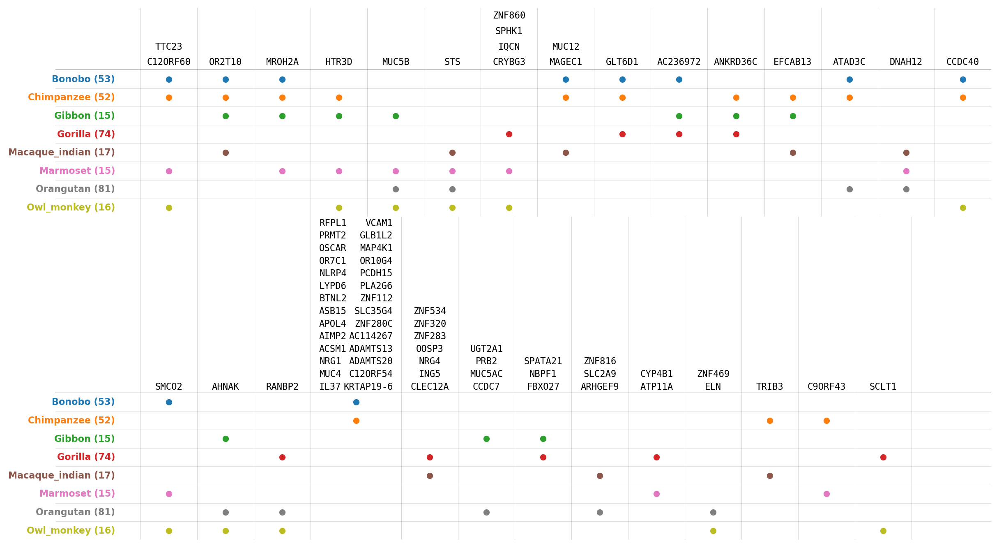

In [4]:
gene_sets = {sp: plot_df.index[(plot_df[sp] == 1)].to_list() for sp in plot_df.columns}
upset(
    gene_sets,
    sort_by='degree',
    # sort_by='groups',
    # sort_by='ordered',
    col_width=0.75,
    set_row_h=0.20,
    size_bar_cols=1,
    dot_empty_color='none',
    #  mode='inclusive',
    gene_pad=0.15,
    label_fontsize=8,
    gene_fontsize=8,
    two_col_ratio=1.6,
    show_count=False,
    wrap=True,
    )

In [ ]:
claudes = matplotlib.colors.LinearSegmentedColormap.from_list('Claudes', ['#FAF9F6', '#C25F3D'], N = 256, bad=None)

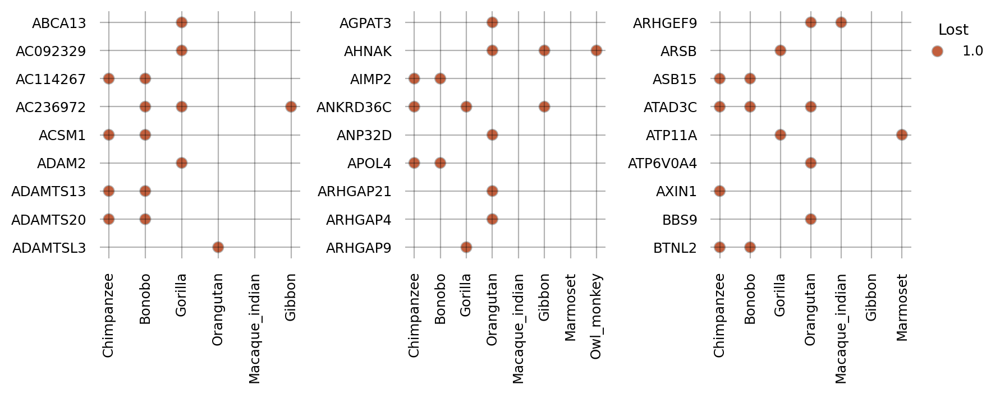

In [65]:
_plot_df = plot_df.reset_index().melt(id_vars='gene', value_vars=None, var_name='species', value_name='Lost').sort_values('gene')
_plot_df['species'] = pd.Categorical(_plot_df.species, ordered=True,
                                     categories=['Chimpanzee', 'Bonobo', 'Gorilla', 'Orangutan', 'Macaque_indian', 'Gibbon', 'Marmoset', 'Owl_monkey'])
_plot_df.loc[_plot_df.Lost == 0] = np.nan
import matplotlib
with sns.plotting_context('paper', font_scale=1):
    nr_cols = 3
    step = (len(plot_df) // nr_cols)
    fig, axes = plt.subplots(1, nr_cols, figsize=(3*nr_cols, max(3, 0.05*step)))
    if len(plot_df) % step:
        step += 1
    for i, n in enumerate(range(0, len(plot_df), step)):
        g = sns.scatterplot(
            data=_plot_df.iloc[n:n+step], ax=axes[i],
            x="species", y="gene", hue="Lost", size="Lost", 
            # palette="vlag", 
            # palette=matplotlib.colors.ListedColormap(['#FAF9F6', '#C25F3D']),
            palette=claudes,
            hue_norm=(-1, 1), edgecolor=".7",            
            sizes=(10, 50), size_norm=(-.2, .8),
            legend=True if n + step > len(plot_df) else False
        )
        axes[i].tick_params(axis='x', labelrotation=90)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    # plt.legend(title='Lost', loc='upper left', labels=['No', 'Yes'])
    sns.move_legend(axes[i], "upper left", bbox_to_anchor=(1, 1))        
    plt.tight_layout()

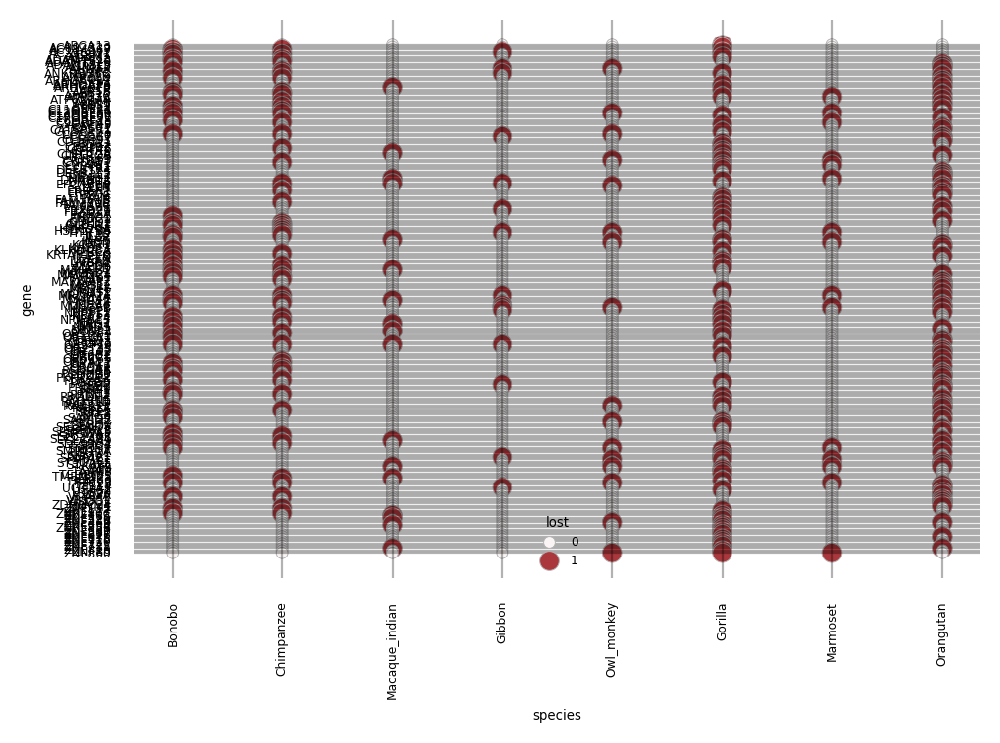

In [17]:
_plot_df = plot_df.reset_index().melt(id_vars='gene', value_vars=None, var_name='species', value_name='lost').sort_values('gene')

with sns.plotting_context('paper', font_scale=0.5):
    g = sns.scatterplot(
        data=_plot_df,
        x="species", y="gene", hue="lost", size="lost", 
        palette="vlag", hue_norm=(-1, 1), edgecolor=".7",
        sizes=(10, 50), size_norm=(-.2, .8),
#        height=15, aspect=1,
    )

    plt.xticks(rotation=90) 
    axes[i].set_ylabel('')

    plt.tight_layout()

In [13]:
_df = df[['gene', 'chrom', 'Bonobo', 'Chimpanzee', 'Gorilla', 'Orangutan']].set_index(['gene', 'chrom']).sum(axis=1).to_frame('nr_loss').reset_index()
_df.loc[lambda d: d.nr_loss > 1].sort_values('nr_loss')

,gene,chrom,nr_loss
4,ABCA17P,16,2
2399,G2E3-AS1,14,2
2410,GARS-DT,7,2
2429,GLB1L2,11,2
2444,GOLGA2P11,15,2
...,...,...,...
1198,AL033530,1,4
4112,RPL10P9,5,4
4118,RPL14P1,12,4
1222,AL078590,6,4


In [2]:
_df.loc[_df.Bonobo, 'gene']


KeyboardInterrupt



In [ ]:
fig = upset(
    dict(
        xbrain=sheet.get('xbrain'),
        transport=genes,
        xyDEG=sheet.get('cDEG') | sheet.get('nDEG'),
        # cDEG=sheet.get('cDEG'),
        # nDEG=sheet.get('nDEG'),
        xi_escape=sheet.get('xi_escape'),
        ari_nonPUR=sheet.get('ari_nonPUR'),
        hybridDEG=sheet.get('hybridDEG'),
        pure_hama=sheet.get('pure_hama'),
        human_nean_admix=sheet.get('hum_nean_admix'),
        circRNA=sheet.get('circRNA'),
        ),
    # sort_by='degree',
    # sort_by='groups',
    sort_by='ordered',
    col_width=0.75,
    set_row_h=0.20,
    size_bar_cols=1,
    dot_empty_color='none',
    #  mode='inclusive',
    gene_pad=0.15,
    label_fontsize=8,
    gene_fontsize=9,
    two_col_ratio=1.5,
    show_count=False,
    wrap=True,
    )

In [7]:
toga_intersections = read_parquet('../results/toga_primates_species.intersections.parquet')
toga_intersections.head()

,query_gene,chrom,lineage,status,all_statuses
0,A1BG,19,ALLENOPITHECUS_NIGROVIRIDIS,PI,PI
1,A1BG,19,ALLOCHROCEBUS_LHOESTI,I,I
2,A1BG,19,ALOUATTA_PALLIATA,I,I
3,A1BG,19,AOTUS_NANCYMAAE,I,I
4,A1BG,19,AOTUS_VOCIFERANS,I,I


In [8]:
toga_long = read_parquet('../results/toga_primates_species.toga_long.parquet')
toga_long.head()

,gene,chrom,lineage,status,assembly,raw_id
0,TRO,X,ALLENOPITHECUS_NIGROVIRIDIS,I,Allenopithecus_nigroviridis__Allens_swamp_monk...,ENSG00000067445
1,EEF1AKMT3,12,ALLENOPITHECUS_NIGROVIRIDIS,PI,Allenopithecus_nigroviridis__Allens_swamp_monk...,ENSG00000123427
2,RAP1B,12,ALLENOPITHECUS_NIGROVIRIDIS,I,Allenopithecus_nigroviridis__Allens_swamp_monk...,ENSG00000127314
3,NPAS3,14,ALLENOPITHECUS_NIGROVIRIDIS,I,Allenopithecus_nigroviridis__Allens_swamp_monk...,ENSG00000151322
4,RRM2B,8,ALLENOPITHECUS_NIGROVIRIDIS,I,Allenopithecus_nigroviridis__Allens_swamp_monk...,ENSG00000048392


In [9]:
toga_loss_matrix = read_parquet('../results/toga_primates_species.loss_matrix.parquet')
toga_loss_matrix.head()

,gene,chrom,ALLENOPITHECUS_NIGROVIRIDIS,ALLOCHROCEBUS_LHOESTI,ALOUATTA_PALLIATA,AOTUS_NANCYMAAE,AOTUS_VOCIFERANS,ATELES_BELZEBUTH,ATELES_CHAMEK,ATELES_GEOFFROYI,...,SAIMIRI_BOLIVIENSIS_BOLIVIENSIS,SAIMIRI_SCIUREUS,SAPAJUS_APELLA,SEMNOPITHECUS_ENTELLUS,SYMPHALANGUS_SYNDACTYLUS,THEROPITHECUS_GELADA,TRACHYPITHECUS_FRANCOISI,TRACHYPITHECUS_GERMAINI,TRACHYPITHECUS_PHAYREI_CREPUSCULA,VARECIA_VARIEGATA
0,A1BG,19,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
1,A1CF,10,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,A2M,12,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,A2ML1,12,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,A3GALT2,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0


In [10]:
toga_loss_matrix.shape

(19457, 132)

In [11]:
chrX_genes = toga_long.loc[toga_long.chrom == 'X', 'gene'].unique()
len(chrX_genes)

843

In [12]:
df = toga_loss_matrix.set_index('gene').loc[chrX_genes].drop(columns='chrom')
df
                                            

,ALLENOPITHECUS_NIGROVIRIDIS,ALLOCHROCEBUS_LHOESTI,ALOUATTA_PALLIATA,AOTUS_NANCYMAAE,AOTUS_VOCIFERANS,ATELES_BELZEBUTH,ATELES_CHAMEK,ATELES_GEOFFROYI,ATELES_MARGINATUS,ATELES_PANISCUS,...,SAIMIRI_BOLIVIENSIS_BOLIVIENSIS,SAIMIRI_SCIUREUS,SAPAJUS_APELLA,SEMNOPITHECUS_ENTELLUS,SYMPHALANGUS_SYNDACTYLUS,THEROPITHECUS_GELADA,TRACHYPITHECUS_FRANCOISI,TRACHYPITHECUS_GERMAINI,TRACHYPITHECUS_PHAYREI_CREPUSCULA,VARECIA_VARIEGATA
gene,,,,,,,,,,,,,,,,,,,,,
TRO,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
MORC4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
CD99,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
HEPH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
SPANXA1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TEX28,0,0,0,0,1,1,0,1,1,1,...,1,1,1,0,0,0,1,0,1,1
ZNF280C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SLITRK4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [13]:


styles = [#dict(selector="th", props=[('width', '40px')]),
          dict(selector="th",props=[('max-width', '20px'), 
                                    # ('padding', '0px'),
                                     ('align', 'bottom')
                                     ]),
            dict(selector="th.col_heading",
                props=[
                    ('padding', '0px'),
                    # ("writing-mode", "vertical-td"),
                    ('transform', 'rotateZ(-90deg)'), 
                    # ('height', '250px'),
                    ])]

def style_negative(v, props=""):
    return props if v == 1 else None


s = (df.style.map(style_negative, props="background-color:red;")
    .set_table_styles(styles)
    # .hide(axis="columns")
    .set_sticky(axis="index")
)

s